In [2]:
#pip install pyidi
#pip install ipywidgets

In [3]:
import sys
print(sys.executable)
print(sys.version)

c:\Users\miha_\AppData\Local\Programs\Python\Python311\python.exe
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


# Uporaba kamer z drsnim zaklopom za brezdotično merjenje vibracij

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

## Nihanje konzolnega nosilca
### Nihajne oblike konzolnega nosilca

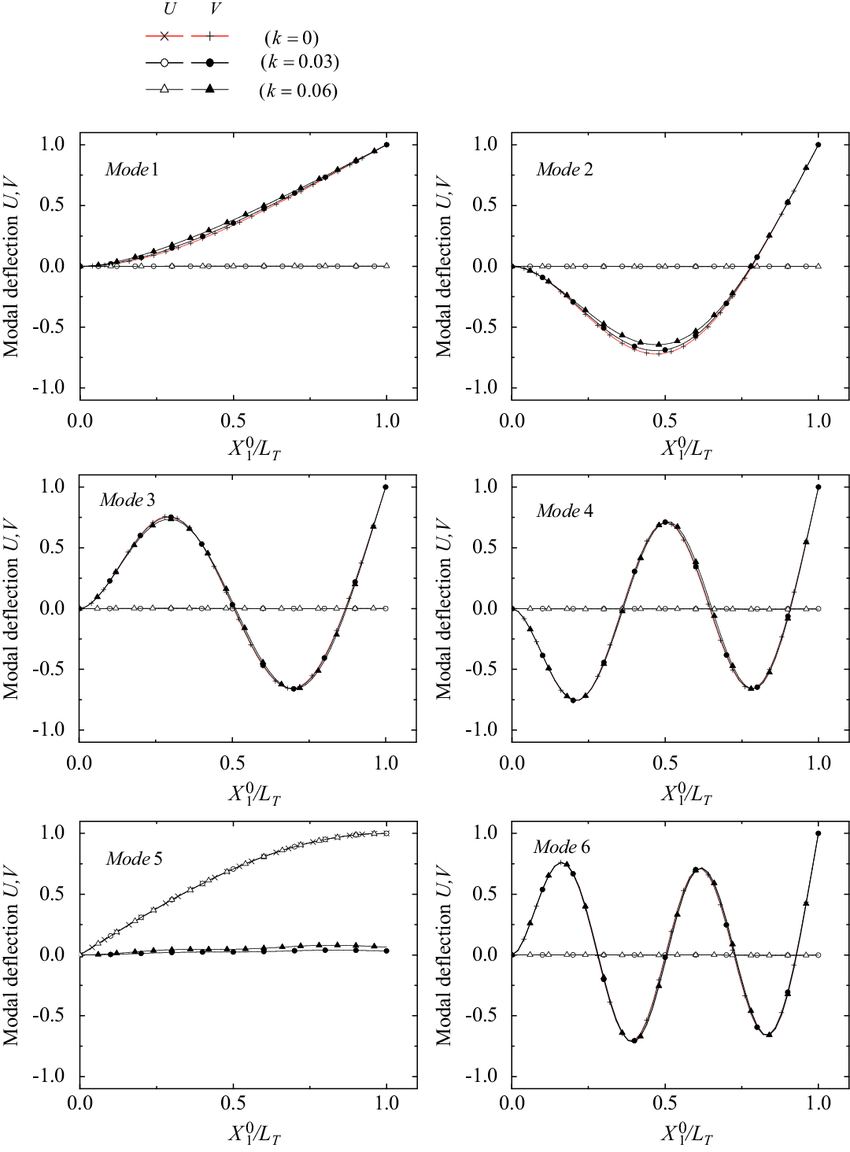

**smiselne enačbe od umetne intiligence**

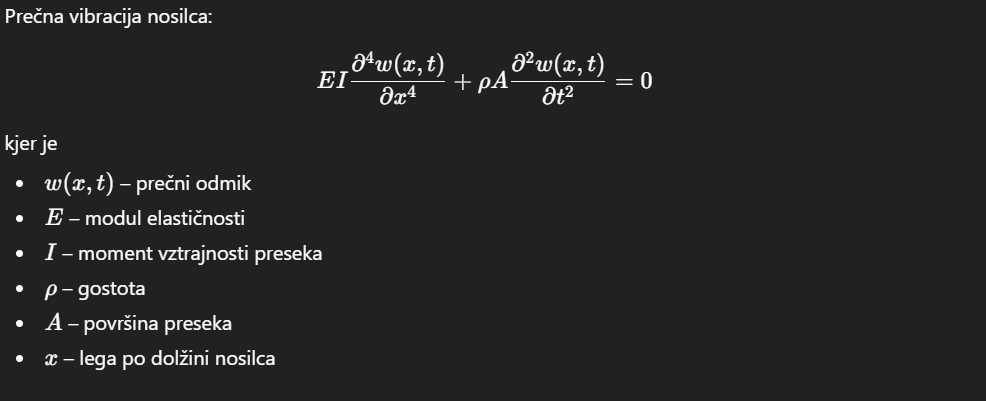
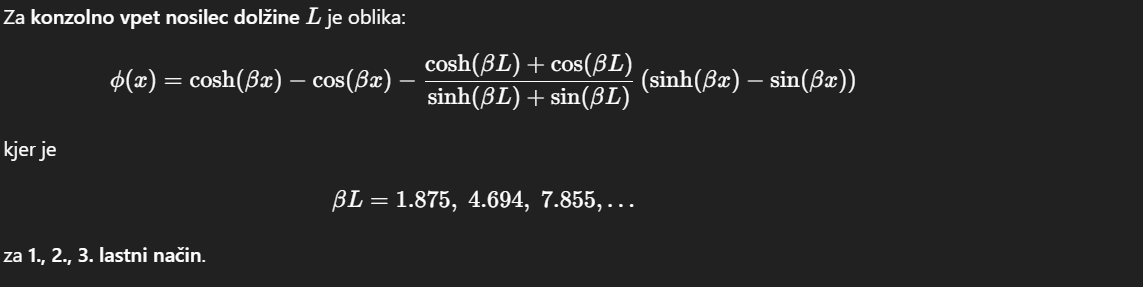

### generiranje funkcije nihajne oblike in izris nihajnih oblik

In [ ]:
import numpy as np

l = 1 #m dolžina nosilca
f = 10 #Hz Lastna frekvenca nosilca
BETA = {"1": 1.875, "2": 4.694, "3": 7.855} 
a = 0.01 #m amplituda
t = 0 # trenutek sprožilca
fi = np.pi/2 # faza zamika med nihanjem kamere in začetkom sprožilca

def nihajna_oblika(L, x, beta, t, f, a, fi, d=0):
    '''L - dolžina nosilca
       x - položaj na nosilcu
       beta - faktor, odvisen od načina pritrditve nosilca
       t - čas
       f - lastna frekvenca nosilca
       a - amplituda
       fi - faza zamika med nihanjem kamere in začetkom sprožilca
       d - razmernik dušenja'''
    C = (np.cosh(beta*L) + np.cos(beta*L)) / (np.sinh(beta*L) + np.sin(beta*L))
    
    return (
        a/2 * np.sin(2*np.pi*f*t+fi) * np.exp(-d*t) *     #a/mora biti da je amplituda realna(nevem zakaj)
        (np.cosh(beta*x)
        - np.cos(beta*x)
        - C*(np.sinh(beta*x) - np.sin(beta*x)))
    )

def nihajna_oblika_strune(L, x, t, f, a, fi, d=0):
    n=1
    return a*np.sin(n*np.pi*x/L)*np.sin(n*2*np.pi*f*t+fi)*np.exp(-d*t)

izris nihajnih oblik

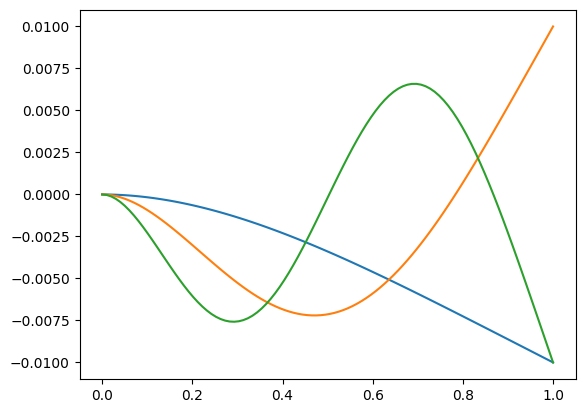

In [ ]:
import matplotlib.pyplot as plt

x = np.linspace(0, l, 100)
plt.plot(x, nihajna_oblika(l, x, BETA["1"], t, f, a, fi))
plt.plot(x, nihajna_oblika(l, x, BETA["2"], t, f, a, fi))
plt.plot(x, nihajna_oblika(l, x, BETA["3"], t, f, a, fi))


## Global shutter

In [ ]:
fps = 10

In [8]:
#privzete nastavitve kamere
x_px = 4056
y_px = 3040

### pretvorba nihajnih oblik v pixle
Predpostavka da v kamero zajememo coloten nosilec dolžine 1m (konzolno vpetje na enem krajšem robu stranice, prosti konec na druhgem).

amplituda nihanja bo za začetek 0.01m (gost material z nizko togostjo --> niska frkvenca)

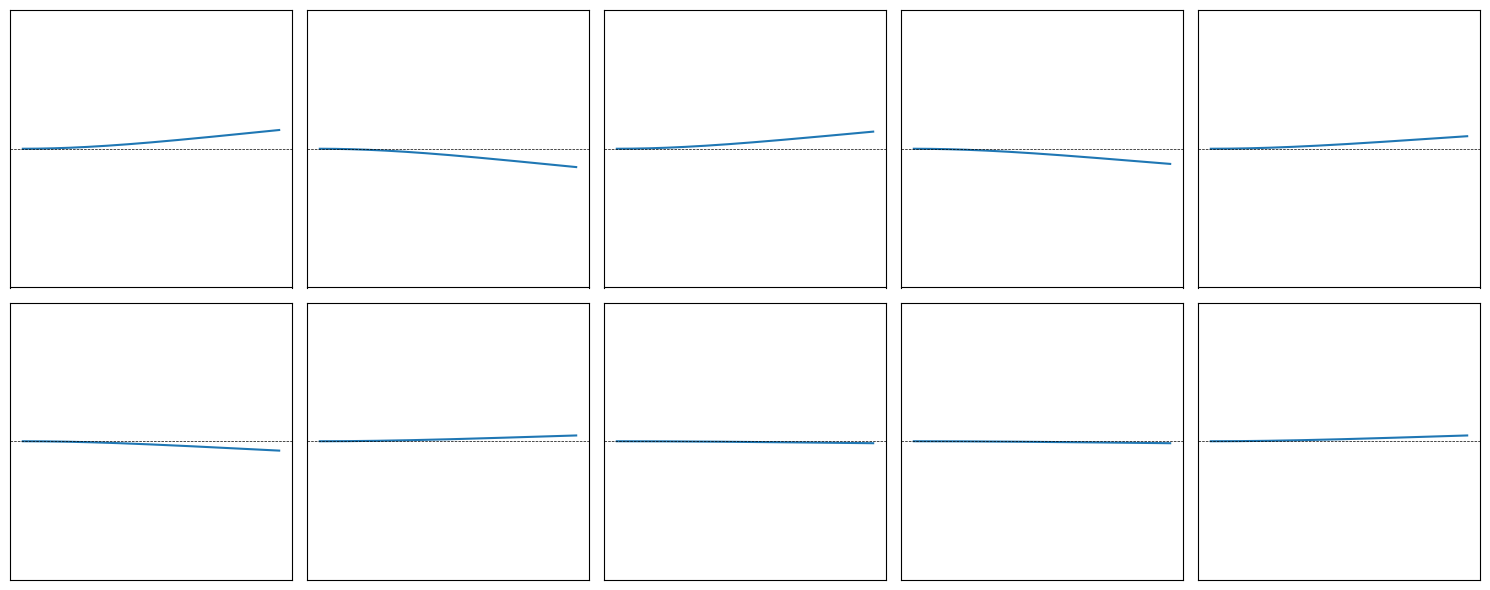

In [ ]:
a = 20 #px
f = 4.8 #Hz Lastna frekvenca nosilca
x = np.arange(0, x_px)
y = np.arange(0, y_px)
#y = np.zeros(y_px)
t= np.linspace(0, 1, fps)


fig, axs = plt.subplots(fps//5, 5, figsize=(15, fps//5*3))

axs = axs.ravel()   # pretvori 2D mrežo v 1D seznam

y = np.zeros(y_px)

crop=1880
for i, ti in enumerate(t):
    
    y = nihajna_oblika(x_px, x, BETA["1"]/x_px, ti, f, a, fi)
    
    axs[i].set_ylim(-y_px/2+crop, y_px/2-crop)
    axs[i].plot(x, y)
    axs[i].set_xticks([])
    axs[i].set_yticks([])
    axs[i].axhline(0, linestyle='--', color='black', lw=0.5)

plt.tight_layout()

analiza nihanja je nemogoča.

slike bi po vsej verjetnosti bile zmazane

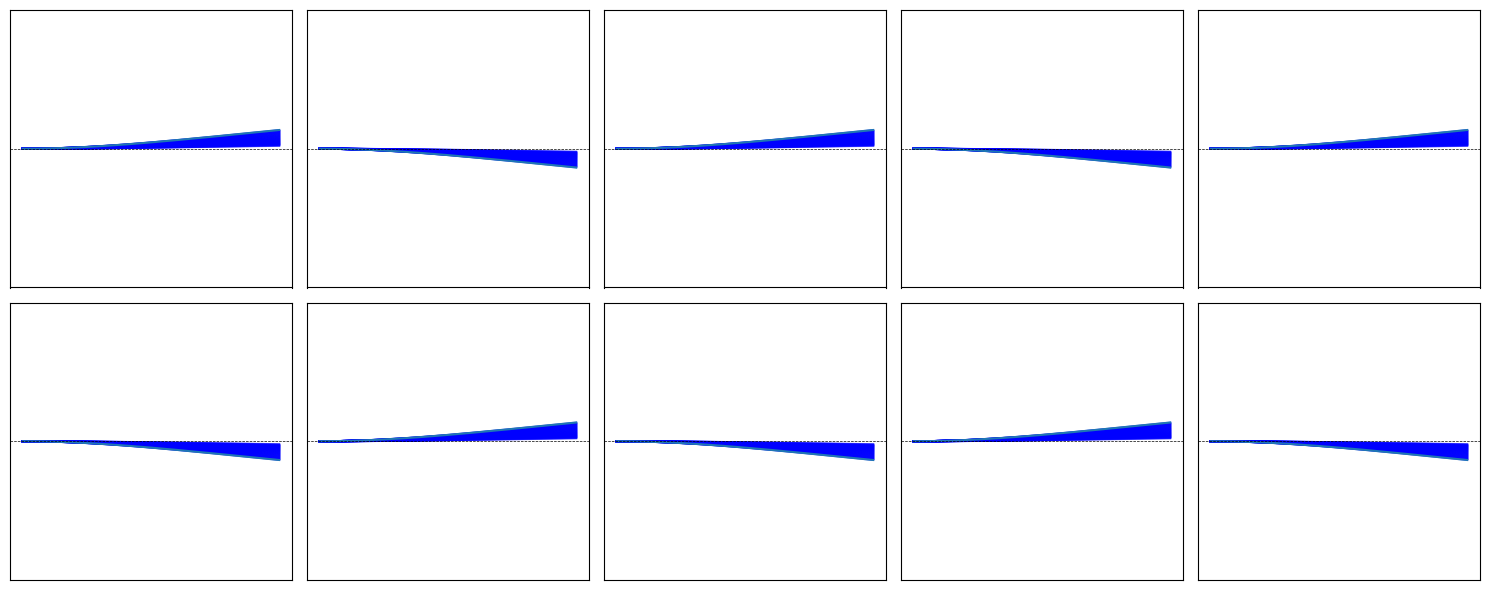

In [ ]:
f = 4.5 #Hz Lastna frekvenca nosilca
x = np.arange(0, x_px)
y = np.arange(0, y_px)
t= np.linspace(0, 1, fps)
a= 20 #px
exposure = 0.05 #s 

fig, axs = plt.subplots(fps//5, 5, figsize=(15, fps//5*3))

axs = axs.ravel()   # pretvori 2D mrežo v 1D seznam

y = np.zeros(y_px)

crop=1880
for i, ti in enumerate(t):
    
    dt = np.linspace(ti, exposure+ti, 100)

    for i_dt, ti_dt in enumerate(dt):
        
        y = nihajna_oblika(x_px, x, BETA["1"]/x_px, ti_dt, f, a, fi)
        axs[i].set_ylim(-y_px/2+crop, y_px/2-crop)
        axs[i].plot(x, y, alpha= 0.01+0.005*i_dt, color='b')

    y = nihajna_oblika(x_px, x, BETA["1"]/x_px, ti, f, a, fi)

    axs[i].set_ylim(-y_px/2+crop, y_px/2-crop)
    axs[i].plot(x, y)
    axs[i].set_xticks([])
    axs[i].set_yticks([])
    axs[i].axhline(0, linestyle='--', color='black', lw=0.5)
    #print(y.max())

plt.tight_layout()

## Rolling shutter

### Kamera
izbira kamere 1:

    Rasberry Pi HQ Camera V1.0 2018
    
        IMX447 Sensor
        5-120 fps Frame rate
        4056 x 3040 maksimum resolution
        8-28 µs Temporal Offset tRow
        sensor: Sony IMX447

Sony dokumentacija navaja rolling shutter with row readout

![Posnetek zaslona 2026-06-16 140310.png](<attachment:Posnetek zaslona 2026-06-16 140310.png>)
![Posnetek zaslona 2026-06-17 090802.png](<attachment:Posnetek zaslona 2026-06-17 090802.png>)

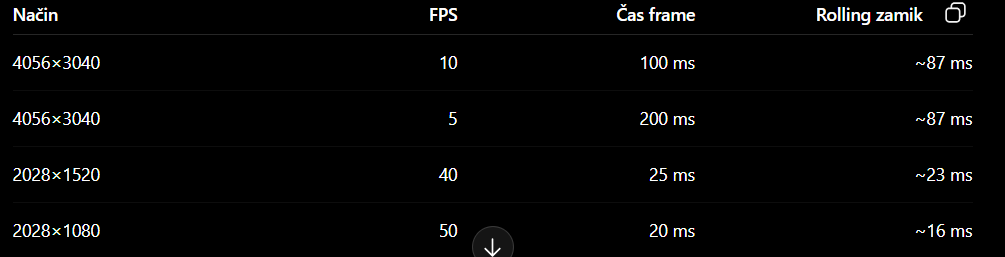
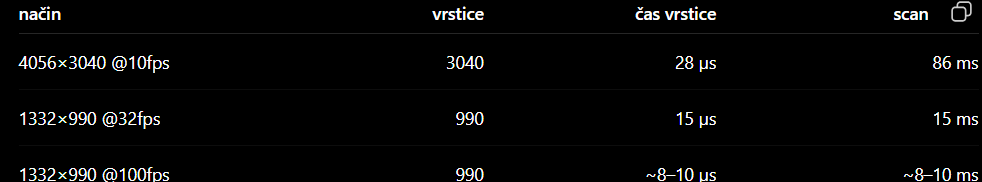

In [ ]:
fps=10
t_row = 28e-6 #s
t_frame = 1/fps

In [37]:
# "vrstice kamere" obrnemo pokončno
x_px = 3040
y_px = 4056
n_rows = x_px

(304,)
(304,)
(304,)
(304,)
(304,)
(305,)
(305,)
(305,)
(305,)
(305,)
(3045,)


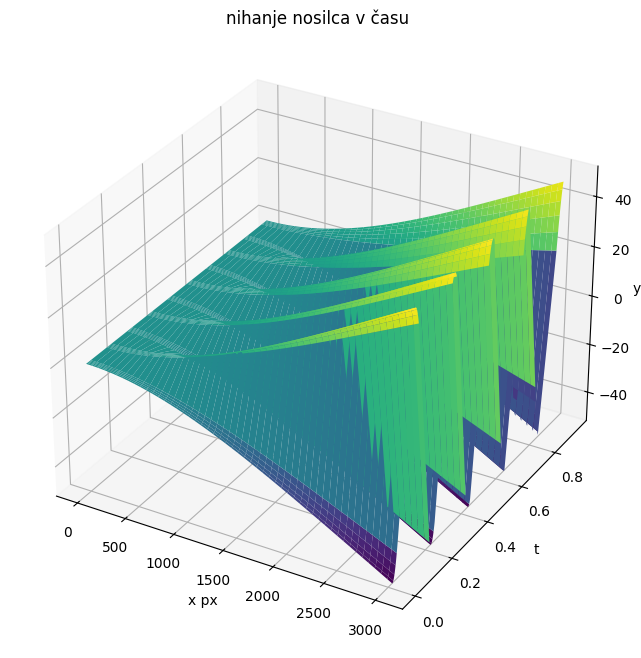

In [ ]:
fps = 10
f = 4.8 #Hz Lastna frekvenca nosilca
a = 50
x = np.arange(0, x_px)
t = np.linspace(0, 1-1/fps, fps)

k = 10 # količnik razrečenja pikslov za lažje računanje

T = np.array([])
for ti in t:
    t_scan = np.arange(ti, ti + n_rows*t_row, k*t_row) # k realnih vrstic je združenih v eno 'ročunsko' vrstico
    print(t_scan.shape)
    T = np.concatenate((T, t_scan))
print(T.shape)

X, T = np.meshgrid(x, T)
Y = nihajna_oblika(x_px, X, BETA["1"]/x_px, T, f, a, fi)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Plottanje površine
surf = ax.plot_surface(X, T, Y, cmap='viridis', edgecolor='none') # 'viridis' je barvna lestvica
ax.set_xlabel('x px')
ax.set_ylabel('t')
ax.set_zlabel('y px')
ax.set_title('nihanje nosilca v času')

plt.show()

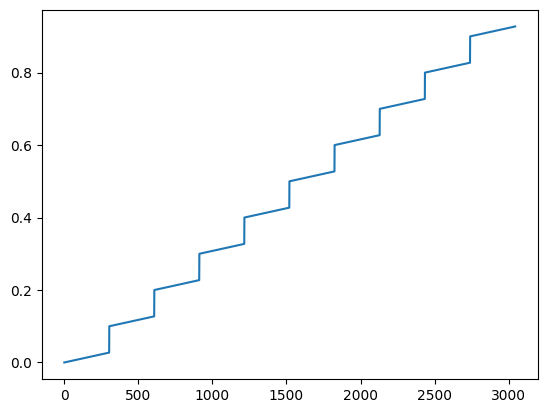

In [41]:
plt.plot(T[:,0])

In [14]:
p1 = np.array([0, 0, 0])
p2 = np.array([0, 0, 1500])
p3 = np.array([2160, 1/fps, 0])

n = np.cross(p3-p1, p2-p1)
n = n/np.linalg.norm(n)
n

array([ 4.62962962e-05, -9.99999999e-01,  0.00000000e+00])

rolling shutter naredi slike kot prereze tega grafa po ravninah $-1.03 \cdot 10^{-5} x + t = n \cdot t_{frame}, \quad n = (1, 2, 3, ...)$ projeciranega na x-y ravnino

In [39]:
print(np.shape(Y))
print(Y.max(), Y.min())

(3045, 3040)
49.97353912645157 -49.97354139920508


(304,)
(304,)
(304,)
(304,)
(304,)
(305,)
(305,)
(305,)
(305,)
(305,)
(3045,)


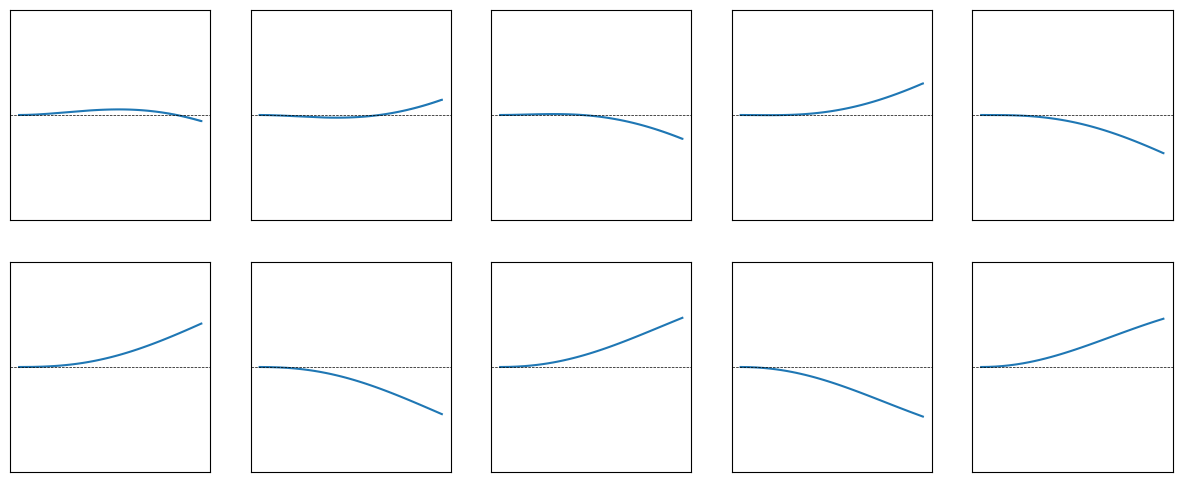

In [ ]:
fps = 10
f = 6.02 #Hz Lastna frekvenca nosilca
a = 70
x = np.arange(0, x_px)
t = np.linspace(0, 1-1/fps, fps)
fi = 2

k = 10 # količnik razrečenja pikslov za lažje računanje

T = np.array([])
for ti in t:
    t_scan = np.arange(ti, ti + n_rows*t_row, k*t_row) # k realnih vrstic je združenih v eno 'ročunsko' vrstico
    print(t_scan.shape)
    T = np.concatenate((T, t_scan))
print(T.shape)

X, T = np.meshgrid(x, T)
Y = nihajna_oblika(x_px, X, BETA["1"]/x_px, T, f, a, fi)

fig, axs = plt.subplots(fps//5, 5, figsize=(15, fps//5*3))

axs = axs.ravel()   # pretvori 2D mrežo v 1D seznam

crop=1880 # obreže sliko za lažje opazovanje nihanja nosilca
for i, ti in enumerate(t):

    y = []
    for j in range(x_px):
        y.append(Y[int(x_px/k)*i+int(j/k), j])

    axs[i].set_ylim(-y_px/2+crop, y_px/2-crop)
    axs[i].plot(x, y)
    axs[i].set_xticks([])
    axs[i].set_yticks([])
    axs[i].axhline(0, linestyle='--', color='black', lw=0.5)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

x_px = 3040
y_px = 4056
fps = 10
a = 250
k = 10
n_rows= x_px
t_row=28e-6

x = np.arange(0, x_px)
t = np.linspace(0, 1-1/fps, fps)

disp = np.load('disp_frames_10fps.npy')[:,:-50]

def narisi(f=6.02, fi=np.pi/4+np.pi, d=0, a=200, save=0):

    T = np.array([])

    for ti in t:
        t_scan = np.arange(ti, ti + n_rows*t_row, k*t_row)
        T = np.concatenate((T, t_scan))

    X, T = np.meshgrid(x, T)

    Y = nihajna_oblika(x_px, X, BETA["1"]/x_px, T, f, a, fi, d)

    fig, axs = plt.subplots(fps//5, 5, figsize=(15, fps//5*3))

    axs = axs.ravel()

    krivulje = []
    ln_rolling, ln_eksperiment, ln_global = None, None, None

    for i, ti in enumerate(t):

        y = [Y[int(x_px/k)*i + int(j/k), j] for j in range(x_px)]
        krivulje.append(y)

        axs[i].set_ylim(-y_px/6, y_px/6)
        axs[i].set_xticks([])
        axs[i].set_yticks([])
        axs[i].axhline(0, linestyle="--", lw=0.5)
        
        l1, = axs[i].plot(x, y, 'blue', label='model rolling shutter')
        l2, = axs[i].plot(disp[i,:,0], -disp[i,:,1]+1050, 'red', label='eksperiment')
        l3, = axs[i].plot(Y[x_px//k*i], 'gray', label='model global shutter')
        
        if i == 0:
            ln_rolling, ln_eksperiment, ln_global = l1, l2, l3

    fig.legend(
        handles=[ln_global, ln_rolling, ln_eksperiment],  
        loc='lower center',                   
        bbox_to_anchor=(0.5, -0.08), 
        ncol=3,                               
        borderaxespad=0,
        fontsize=18,
        handlelength=5,
    )

    plt.tight_layout(rect=[0, 0.025, 1, 1])

    if save == 1:
        np.save(f'simulirane_krivulje_{fps}fps', krivulje)
        print('shranjeno')
    plt.show()


widgets.interactive(
    narisi,
    f = widgets.FloatText( value=5.78, min=0.1, max=20, step=0.01, description="f [Hz]"),
    fi = widgets.FloatText(value=3.63, min=0, max=2*np.pi, step=0.01, description="fi [rad]"),
    d = widgets.FloatText( value=0.5, min=0, max=1, step=0.001, description='dušenje'),
    a = widgets.FloatText( value=164, step=1, description='amplituda')

)

interactive(children=(FloatText(value=5.78, description='f [Hz]', step=0.01), FloatText(value=3.63, descriptio…

# PRIMERJAVA

In [ ]:
k = 10

def rolling_vs_global(change=None):
    plt.close('all') 
    
    with output_box:
        output_box.clear_output(wait=True)
        
        try:
            fps = w_fps.value
            B = BETA[w_Beta.value]
            f = w_f.value
            a = w_a.value
            fi = w_fi.value
            roi_y = w_roi_y.value

            if fps > 10 and fps <=40:
                x_px = 1520
                y_px = 2028
                t_row = 25e-6
            elif fps > 40:
                x_px = 990
                y_px = 1331
                t_row = 15e-6    
            elif fps <= 10:
                x_px = 3040
                y_px = 4056
                t_row = 28e-6
            n_rows=x_px
            
            t_row_max = 1/(fps*n_rows)
            if t_row > t_row_max:
                t_row = t_row_max

            print(f'število vrstic: {x_px}')
            print(f'čas vrstice: {t_row} s')

            if w_roi_y.value < 0 or w_roi_y.value >= y_px/2-5:
                raise Exception(f"'ROI' mora biti med 0 in {y_px/2-5} (px), trenutno je {w_roi_y.value}")

            x = np.arange(0, x_px)
            n_rows = x_px

            t = np.linspace(0, 1-1/fps, fps)
            T = np.array([])

            vsebina_skeniranja = np.arange(0, n_rows, k) * t_row

            for ti in t:
                t_scan = ti + vsebina_skeniranja
                T = np.concatenate((T, t_scan))

            Y = []
            for Ti in T:
                Y.append(nihajna_oblika_strune(x_px, x, Ti, f, a, fi))
            Y = np.array(Y)

            # Ustvarjanje slike
            fig, axs = plt.subplots(fps//5 + (1 if fps % 5 != 0 else 0), 5, 
                                    figsize=(16, 3 * (fps//5 + (1 if fps % 5 != 0 else 0))))
            axs = axs.ravel()

            for i, ti in enumerate(t):   
                axs[i].axhline(0, linestyle='--', color='black', lw=0.5)
                axs[i].set_xticks([])
                axs[i].set_yticks([])

                # Global shutter 
                if w_global.value == True:    
                    dt = np.linspace(ti - 1/fps, ti, 100)
                    for i_dt, ti_dt in enumerate(dt):
                        y_plot = nihajna_oblika_strune(x_px, x, ti_dt, f, a, fi)
                        axs[i].plot(x, y_plot, alpha=0.01+0.001*i_dt, color='blue')
                
                y_plot = nihajna_oblika_strune(x_px, x, ti, f, a, fi)
                axs[i].plot(x, y_plot, color='green')

                # Rolling shutter
                if w_rolling.value == True:    
                    for i_dt in range(-100, 0):
                        # --- OPTIMIZACIJA TUKAJ ---
                        # Namesto 'for j in range(n_rows)' vzamemo celo vrstico naenkrat z numpy indeksiranjem:
                        j_indices = np.arange(n_rows)
                        row_indices = (int(n_rows/k) * i + (j_indices // k) + i_dt).astype(int)
                        y_plot = Y[row_indices, j_indices]
                        axs[i].plot(x, y_plot, alpha=0.11+0.001*i_dt, color='orange')

                # Osnovni rolling shutter izris
                j_indices = np.arange(n_rows)
                row_indices = (int(n_rows/k) * i + (j_indices // k)).astype(int)
                y_plot = Y[row_indices, j_indices]

                axs[i].set_ylim(-roi_y/2, roi_y/2)
                axs[i].plot(x, y_plot, color='red')

            if fps % 5 != 0:
                for o in range(5 - (fps % 5)):
                    axs[fps + o].axis('off')

            fig.tight_layout()
            
            # 3. KLJUČNI POPRAVEK ZA IPYWIDGETS:
            # Eksplicitno prikažemo sliko znotraj widgeta in jo nato zapremo za matplotlib pomnilnik
            from IPython.display import display
            display(fig)
            plt.close(fig) 
            
        except Exception as e:
            print(e)

import ipywidgets as widgets
from IPython.display import display

style_args = {'description_width': '200px'}
imput_layout = widgets.Layout(width='300px')

w_fps = widgets.IntText(value=10, min=1, step=1,
                        description='FPS',
                        style=style_args, layout=imput_layout,)

w_f = widgets.FloatText(value=50, min=1, step=1,
                        description='f [Hz]',
                        style=style_args, layout=imput_layout,
                        readout_format='1.2f')

w_roi_y = widgets.IntText(value=40, min=0, max=y_px/2-5, step=1,
                        description="ROI y [px]",
                        style=style_args, layout=imput_layout,
                        readout_format='1.2f')

w_a = widgets.FloatText(value=10, min=0.5, max=10, step=0.5,
                        description='Amplituda [px]',
                        style=style_args, layout=imput_layout,
                        readout_format='1.2f')

w_fi = widgets.FloatText(value=0, min=0, max=2*np.pi, step=0.25*np.pi,
                        description='Faza nihanja ob času sprožilca',
                        style=style_args, layout=imput_layout,
                        readout_format='1.2f')

w_rolling = widgets.Checkbox(value=False,
                            description='zmazek RS',
                            indent=False)
w_global = widgets.Checkbox(value=False,
                            description='zmazek GS',
                            indent=False)

w_Beta  = widgets.Dropdown(options=BETA.keys(),  description='Nihanja oblika', value='1', style={'description_width': '200px'})

output_box = widgets.Output(layout={'border':'1px solid #444', 'padding':'10px'})

all_widgets =  [w_fps, w_f, w_roi_y, w_a, w_fi, w_rolling, w_global, w_Beta]
for widget in all_widgets:
    widget.observe(rolling_vs_global, names='value')

ui = widgets.VBox([
                   widgets.HTML('<h1>Rolling shutter vs global shutter'),
                   widgets.HTML('<h2>Navodilo za uporabo:'),
                   widgets.HTML('Funkcija splota teoretične slike nihanja nosilca snemanega z globalnim in rolling shutterjem. '
                                'Nihanje obravnava v časovnem intervalu 1s. Zaporedno izriše vse slike ki bi nastale med snemanjem. '
                                '(parametre je bolje spreminati, ko sta izrisa odkljukana). '
                                "parametri kamere razen FPS niso tako pomebni za analizo delavanja, prav tako tudi amplituda in 'ROI'. "
                                "'ROI' ni dejansi ROI, ampak zgolj koliko zgornih vrstic in spodnjih vrstic je odrezanih (da se laže opazuje lego nosilca)" ),
                   widgets.HTML('<h2>Parametri'),
                   widgets.HTML('parametri kamere:'),
                   widgets.HBox([widgets.VBox([w_fps, w_roi_y,]),
                                 widgets.Box([], layout=widgets.Layout(width='150px')),
                                 widgets.VBox([w_rolling, w_global,])]),
                   widgets.HTML('<br>'),
                   widgets.HTML('parametri nihanja:'),
                   widgets.HBox([w_f, w_a, w_Beta, w_fi]),
                   widgets.HTML('<br>'),
                   widgets.HTML('rolling shutter je prikazan z rdečo barvo, global shutter z zeleno barvo, modra barva prikazuje zmazek global shutterja, oranžna barva zmazek rolling shutterja, pozicija ob začetku sprožilca z zeleno barvo'),
                   output_box 
                   ])
rolling_vs_global()

display(ui)

# Opažanja

**Pomembno je le razmerje med FPS in frekvenco nihanja, ne pa njuni absulutni vrednosti**

1. nihajna oblika:
- ob makismalnem amplitudi rolling shutter dobro zajame nihanje.

2. nihajna oblika (fps 10x frekvenci nihanja):
- ob makismalnem amplitudi rolling shutter dobro zajame nihanje.


# Sivina

- **Optika (največji vpliv)**

Vsak objektiv ima končno ločljivost. To opisuje Point Spread Function.

ena točka v resnici postane majhna “packa” svetlobe
rob se “razmaže”

Rezultat je tipičen S-prehod:

idealno:   █████│     
realno:    ███▓▒░    
-  **Difrakcija**

Svetloba se na robovih uklanja (valovna narava svetlobe):

tudi perfekten objektiv ne more dati neskončno ostrega roba
meja je določena z difrakcija
- **Velikost piksla (sampling)**

Tvoj senzor (npr. Sony IMX334) ima:

pixel ≈ 2 µm

Če rob pade med dva piksla, oba dobita del svetlobe:

en piksel: 30% svetlobe
drugi: 70%

→ oba sta siva

To je prostorsko vzorčenje (sampling).

- **Fokus**

Če slika ni popolnoma izostrena:

rob se še dodatno razširi
prehod postane širši
- **Gibanje (motion blur)**

predolg exposure
vibracije

se rob “razmaže” v smeri gibanja.

- **Elektronika in šum**

Tudi če bi bil rob perfekten:

šum senzorja
kvantizacija (8-bit = 256 sivin)

dodajo mehkejši prehod.

- **Odboji in svetloba**

“Črn” objekt v praksi ni popolnoma črn:

odbija nekaj svetlobe
svetloba se odbija od okolice

→ rob ni idealen kontrast.

- **Kako se to matematično opiše**

Idealni rob:

I(x)=step funkcija

realni rob:

I(x)=step∗PSF

(* konvolucija)

bolj “oster” prehod:

zapri zaslonko (večji f-number)
boljši objektiv
boljši fokus
krajši exposure
večja kontrastna osvetlitev (backlight)

Povzetek:

Sivinski prehod nastane zaradi kombinacije:

optike (PSF)
difrakcije
velikosti pikslov
fokusa
gibanja

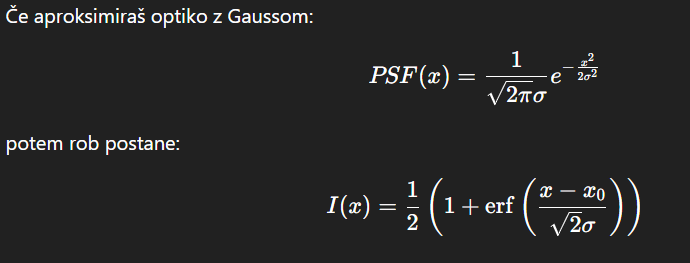

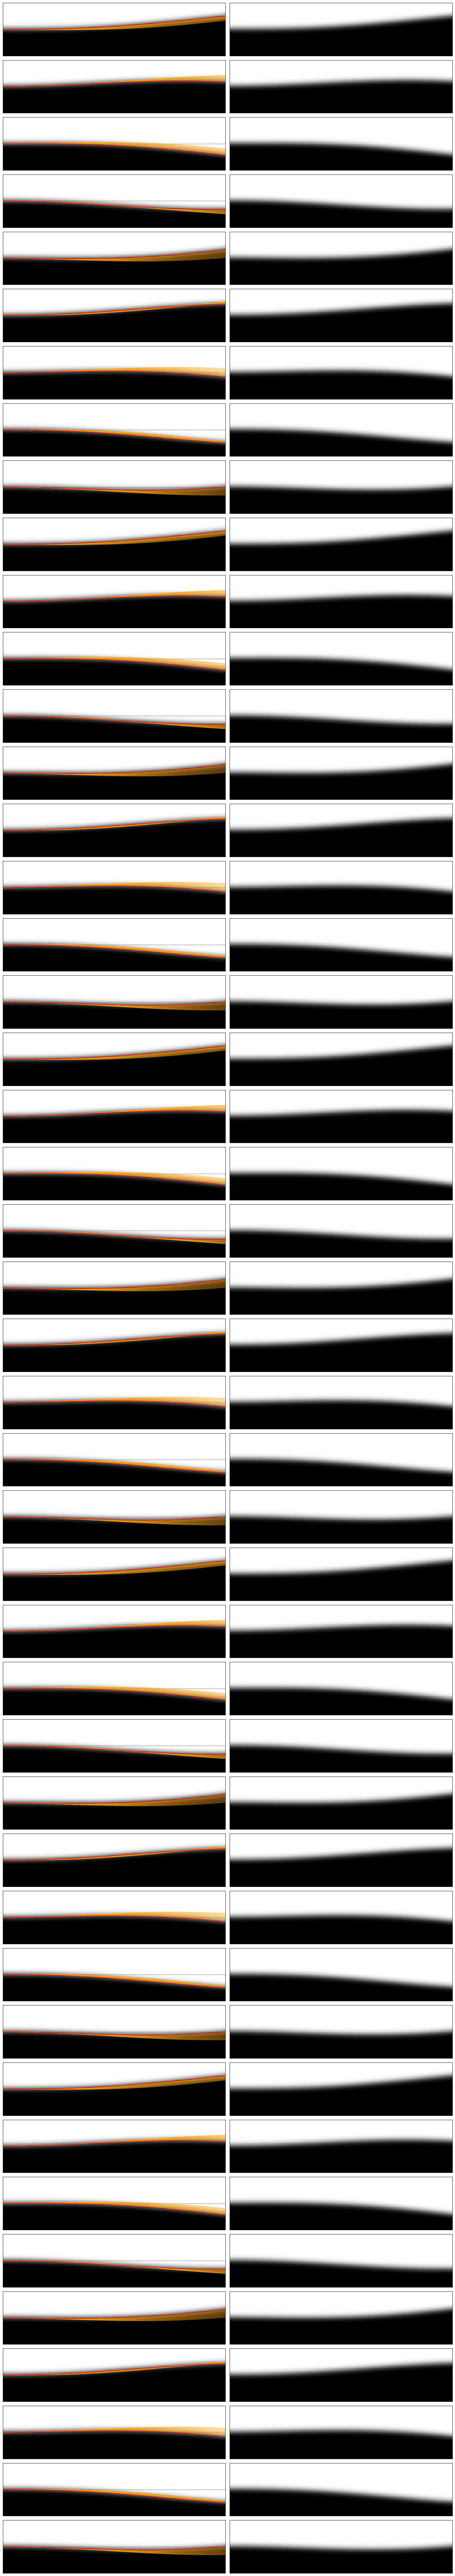

In [ ]:
from scipy.special import erf
sigma = 2 #standardna deviacija

fps= 45
x_px = 2160
y_px = 3840
B = BETA["1"]
f = 10
a = 10
fi = 0
roi = 40 # določi y območjeza lažje opazovanje nihanja nosilca
k = 10 # količnik razrečenja pikslov za hitrejše računanje

x = np.arange(0, x_px)
y = np.arange(0, y_px)
t_snap = np.linspace(0, 1-1/fps, fps) # [0, 1) interval, deljen na število sličic

n_rows = x_px

T = np.linspace(0, 1-1/(fps*int(n_rows/k)), fps*int(n_rows/k)) # lahko bi bolje popisal časovni interval (dejsnsi razmak ne lispace), a ga zaradi neznaja numpyja trenuno neznam.

Y = []
for Ti in T:
    Y.append(nihajna_oblika(x_px, x, B/x_px, Ti, f, a, fi))
Y = np.array(Y)

fig, axs = plt.subplots(fps, 2, figsize=(16, 2 * fps))


Y_pixel =[]
for i, ti in enumerate(t_snap):   
    axs[i,0].axhline(0, linestyle='--', color='black', lw=0.5)
    axs[i,0].set_xticks([])
    axs[i,0].set_yticks([])
    axs[i,1].set_xticks([])
    axs[i,1].set_yticks([])

# rolling shutter
    zmazek = []
    for i_dt in range(-10,0):
        y_zmazek=[]
        for j in range(n_rows):
            y_zmazek.append(Y[int(n_rows/k)*i+int(j/k)+i_dt*10, j])
        axs[i,0].plot(x, y_zmazek, alpha= 0.5, color='orange')
        zmazek.append(y_zmazek)
    zamzek = np.array(zmazek)

    y = []
    for j in range(n_rows):
        y.append(Y[int(n_rows/k)*i+int(j/k), j])

    axs[i,0].set_ylim(-roi/2, roi/2)
    axs[i,0].plot(x, y, color='red')

#sivina
    pixel_grid = np.zeros((roi, x_px//k))

    for iy in range(roi):   # indeks (0 … roi-1)

        py = iy - roi/2     # fizična koordinata (−roi/2 … +roi/2)

        for px in range(x_px//k):

            j = int(px * k)

            pixel_grid[iy, px] = 256 * (0.5 * (1 + erf((py - y[j]) / (np.sqrt(2)*sigma))))-1
            #treba je dodati se motion blure

    axs[i,0].imshow(pixel_grid, cmap='gray', vmin=0, vmax=255, origin='lower', extent=[0, x_px, -roi/2, roi/2], aspect='auto')
    axs[i,1].imshow(pixel_grid, cmap='gray', vmin=0, vmax=255, origin='lower', extent=[0, x_px, -roi/2, roi/2], aspect='auto')

    Y_pixel.append(pixel_grid)
Y_pixel = np.array(Y_pixel)

fig.tight_layout()

#sum na piksle
#deljena vrednost samo na robu

Y_pixel: **frame** x **y_px** x **x_px**    [**sivina**]

# pomik, hitrost, pospesek sivine

predpostavimo da je gradient po času mnogo večji kot gradient po x-u

tako je hitrost v točki enaka:
$\frac{sivina[x-1] - sivina[x+1]}{dt}$

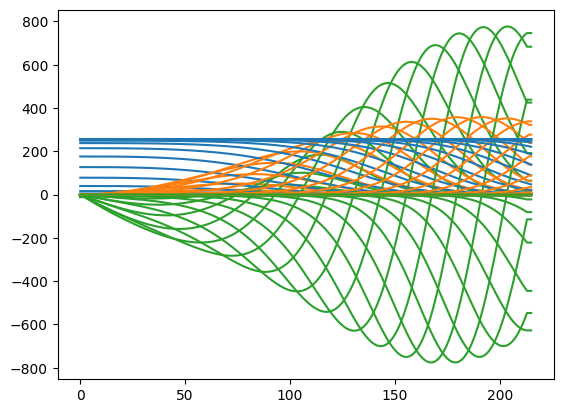

In [19]:
for i in range(roi):
    x = Y_pixel[0, i, :]

    v = []
    for i in range(1, len(x)-1):
        vi = (x[i-1]-x[i+1])/(1/fps)
        v.append(vi)
    v = [v[0]] + v + [v[-1]]

    a = []
    for i in range(2, len(v)-2):
        ai = (v[i-1]-v[i+1])/(1/fps)
        a.append(ai)
    a = [a[0], a[0]] + a + [a[-1], a[-1]]

    plt.plot(x, color='C0')
    plt.plot(v, color='C1')
    plt.plot(a, color='C2')

Hitrosti in pospeški se razlikujejo po tem kateri stolpec 'vrstica' pixlov se gleda

# Sestavljena časovna odvisnost hitrosti in pospeška posamezne točke

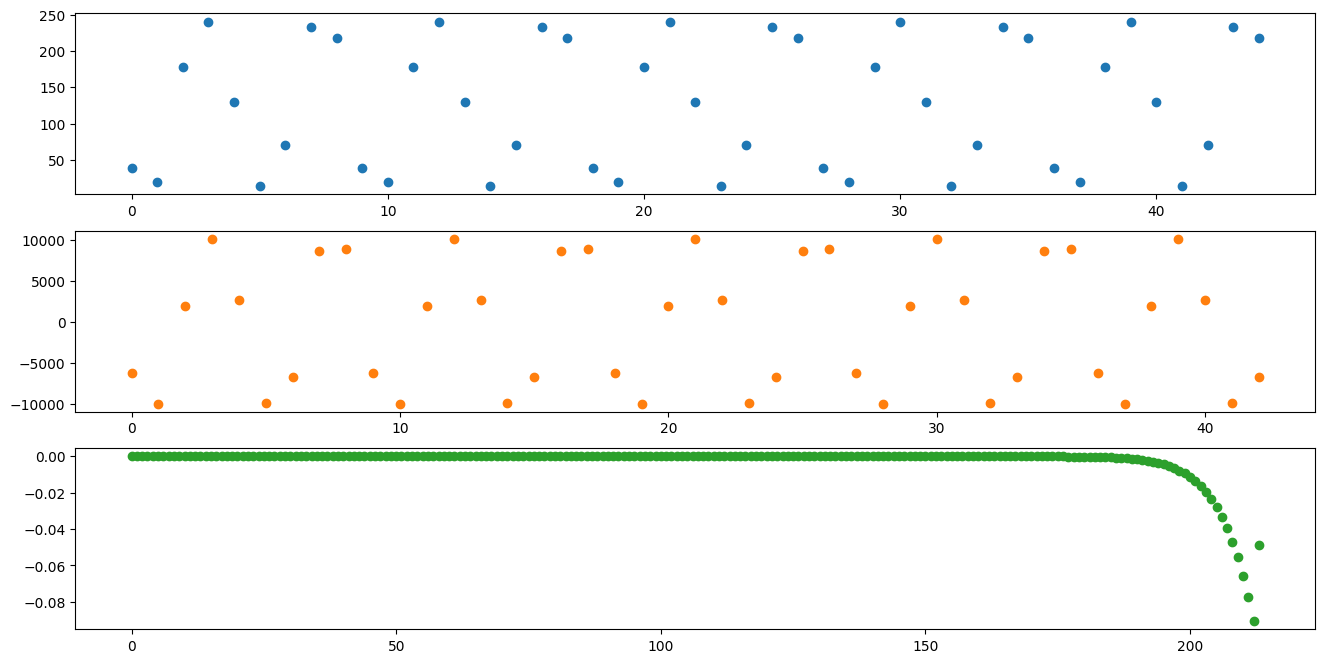

In [20]:
t = 105 # točka

x_5 = Y_pixel[:, roi//2, t-2:t+3] #točke v okolici t, v vseh trenutkih 

v_3 = []
for i in range(1, len(x_5)-1):
    vi = (x_5[i-1]-x_5[i+1])/(1/fps)
    v_3.append(vi)
v_3 = np.array(v_3)

a = []
for i in range(1, len(v)-1):
    ai = (v[i-1]-v[i+1])/(1/fps)
    a.append(ai)
a = np.array(a)

fig, axs = plt.subplots(3, 1, figsize=(16, 8))
axs[0].plot(x_5[:, 2], 'o', color='C0')
axs[1].plot(v_3[:, 1], 'o', color='C1')
axs[2].plot(a, 'o', color='C2')